# FEM with Lagrange Interpolation: Linear Elements, Cubic Element, Assembly, and Boundary Conditions

The same Lagrange interpolation formula used in the earlier notebook is used here:

$$
N_i(x)=
\prod_{\substack{j=1\\j\neq i}}^{n}
\frac{x-x_j}{x_i-x_j}.
$$



# 1. Import libraries

In [79]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 2. General Lagrange basis function

This is the same product definition used in the provided Lagrange-interpolation in Week #4 lectures.



In [80]:
def lagrange_basis(x, nodes, i):
    # Start the product with 1
    N = 1

    # Multiply all terms except j = i
    for j in range(len(nodes)):
        if j != i:
            N = N * (x - nodes[j]) / (nodes[i] - nodes[j])

    return N

---
# Problem 1

Solve

$$
-\frac{d^2u}{dx^2}=\cos(\pi x),
\qquad 0<x<1
$$

with

$$
u(0)=0,
\qquad
u(1)=0.
$$

The exact solution is

$$
\boxed{
u(x)=\frac{1}{\pi^2}
\left[\cos(\pi x)+2x-1\right]
}.
$$

# 3. Weak form

Starting with

$$
-u''=\cos(\pi x),
$$

multiply by the weighting function $v$:

$$
-\int_0^1 u''v\,dx
=
\int_0^1 \cos(\pi x)v\,dx.
$$

Integrating the left side by parts,

$$
\int_0^1 u'v'\,dx
-
\left[u'v\right]_0^1
=
\int_0^1 \cos(\pi x)v\,dx.
$$

Because

$$
u(0)=u(1)=0,
$$

the admissible weighting functions satisfy

$$
v(0)=v(1)=0.
$$

Therefore,

$$
\boxed{
\int_0^1u'v'\,dx
=
\int_0^1\cos(\pi x)v\,dx
}.
$$

For any Lagrange basis functions,

$$
K_{ij}
=
\int
\frac{dN_i}{dx}
\frac{dN_j}{dx}\,dx
$$

and

$$
F_i
=
\int
N_i(x)\cos(\pi x)\,dx.
$$

# 4. Uniform physical nodes

For three linear elements,

$$
x_1=0,\qquad
x_2=\frac13,\qquad
x_3=\frac23,\qquad
x_4=1.
$$

The element connectivity is

$$
e_1=(1,2),\qquad
e_2=(2,3),\qquad
e_3=(3,4).
$$

In [81]:
# Symbol used for exact integration
x = sp.symbols('x')

# Four uniformly spaced physical nodes
nodes = [
    sp.Rational(0, 1),
    sp.Rational(1, 3),
    sp.Rational(2, 3),
    sp.Rational(1, 1)
]

nodes_float = np.array([float(value) for value in nodes])

print("Uniform nodes =", nodes_float)

Uniform nodes = [0.         0.33333333 0.66666667 1.        ]


# 5. Three 2-node linear elements

For each element, we simply take its two physical end points and generate its two Lagrange functions.

For an element with nodes $x_a$ and $x_b$,

$$
u^e(x)=N_1(x)u_a+N_2(x)u_b.
$$

No coordinate transformation is required because the basis functions are generated directly using the physical coordinates.

In [82]:
# ============================================================
# THREE LINEAR ELEMENTS:
# ELEMENT MATRICES -> GLOBAL ASSEMBLY -> BOUNDARY CONDITIONS
# ============================================================

# Number of global nodes
n_nodes = 4

# ------------------------------------------------------------
# GLOBAL MATRIX AND LOAD VECTOR
# Start with zeros
# ------------------------------------------------------------

K_global = np.zeros((n_nodes, n_nodes))
F_global = np.zeros(n_nodes)


# ------------------------------------------------------------
# ELEMENT CONNECTIVITY
#
# Physical nodes:
#
# Node 1 ----- Node 2 ----- Node 3 ----- Node 4
#   0           1/3          2/3           1
#
# Element 1: nodes 1-2
# Element 2: nodes 2-3
# Element 3: nodes 3-4
#
# Python indexing starts from zero.
# ------------------------------------------------------------

connectivity = [
    [0, 1],    # Element 1
    [1, 2],    # Element 2
    [2, 3]     # Element 3
]


# ============================================================
# ELEMENT LOOP
# ============================================================

for e in range(3):

    print("\n==========================================")
    print("ELEMENT", e + 1)
    print("==========================================")

    # --------------------------------------------------------
    # Find the global node numbers of this element
    # --------------------------------------------------------

    node1 = connectivity[e][0]
    node2 = connectivity[e][1]

    # Physical coordinates of the two nodes
    x1 = nodes[node1]
    x2 = nodes[node2]

    local_nodes = [x1, x2]

    print("Global nodes =", [node1 + 1, node2 + 1])
    print("Coordinates =", [float(x1), float(x2)])


    # --------------------------------------------------------
    # GENERATE LINEAR LAGRANGE BASIS FUNCTIONS
    #
    # N1(x) = Lagrange function associated with local node 1
    # N2(x) = Lagrange function associated with local node 2
    # --------------------------------------------------------

    N1 = sp.simplify(
        lagrange_basis(x, local_nodes, 0)
    )

    N2 = sp.simplify(
        lagrange_basis(x, local_nodes, 1)
    )

    N = [N1, N2]

    print("\nLagrange basis functions:")

    print("N1(x) =")
    sp.pprint(N1)

    print("N2(x) =")
    sp.pprint(N2)


    # ========================================================
    # ELEMENT STIFFNESS MATRIX
    #
    # Ke_ij = integral(dNi/dx * dNj/dx dx)
    # ========================================================

    Ke = np.zeros((2, 2))

    for i in range(2):

        for j in range(2):

            Ke[i, j] = float(
                sp.integrate(
                    sp.diff(N[i], x) *
                    sp.diff(N[j], x),

                    (x, x1, x2)
                )
            )


    # ========================================================
    # ELEMENT LOAD VECTOR
    #
    # Fe_i = integral(Ni * cos(pi*x) dx)
    # ========================================================

    Fe = np.zeros(2)

    for i in range(2):

        Fe[i] = float(
            sp.integrate(
                N[i] * sp.cos(sp.pi*x),

                (x, x1, x2)
            )
        )


    print("\nElement stiffness matrix Ke:")
    print(Ke)

    print("\nElement load vector Fe:")
    print(Fe)


    # ========================================================
    # GLOBAL ASSEMBLY
    # ========================================================

    # Global degree-of-freedom numbers for this element
    dofs = connectivity[e]

    for i in range(2):

        # Local load contribution -> global load vector
        I = dofs[i]

        F_global[I] += Fe[i]

        for j in range(2):

            # Local stiffness contribution -> global matrix
            J = dofs[j]

            K_global[I, J] += Ke[i, j]


    # --------------------------------------------------------
    # Show how the GLOBAL system changes after every element
    # --------------------------------------------------------

    print("\nGlobal K after assembling Element", e + 1)
    print(K_global)

    print("\nGlobal F after assembling Element", e + 1)
    print(F_global)


ELEMENT 1
Global nodes = [1, 2]
Coordinates = [0.0, 0.3333333333333333]

Lagrange basis functions:
N1(x) =
1 - 3⋅x
N2(x) =
3⋅x

Element stiffness matrix Ke:
[[ 3. -3.]
 [-3.  3.]]

Element load vector Fe:
[0.15198178 0.12368267]

Global K after assembling Element 1
[[ 3. -3.  0.  0.]
 [-3.  3.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

Global F after assembling Element 1
[0.15198178 0.12368267 0.         0.        ]

ELEMENT 2
Global nodes = [2, 3]
Coordinates = [0.3333333333333333, 0.6666666666666666]

Lagrange basis functions:
N1(x) =
2 - 3⋅x
N2(x) =
3⋅x - 1

Element stiffness matrix Ke:
[[ 3. -3.]
 [-3.  3.]]

Element load vector Fe:
[ 0.0282991 -0.0282991]

Global K after assembling Element 2
[[ 3. -3.  0.  0.]
 [-3.  6. -3.  0.]
 [ 0. -3.  3.  0.]
 [ 0.  0.  0.  0.]]

Global F after assembling Element 2
[ 0.15198178  0.15198178 -0.0282991   0.        ]

ELEMENT 3
Global nodes = [3, 4]
Coordinates = [0.6666666666666666, 1.0]

Lagrange basis functions:
N1(x) =
3 - 3⋅x
N2(x) =

In [83]:
# ============================================================
# COMPLETED GLOBAL SYSTEM
# ============================================================

print("Final Global Stiffness Matrix:")
print(K_global)

print("\nFinal Global Load Vector:")
print(F_global)

Final Global Stiffness Matrix:
[[ 3. -3.  0.  0.]
 [-3.  6. -3.  0.]
 [ 0. -3.  6. -3.]
 [ 0.  0. -3.  3.]]

Final Global Load Vector:
[ 0.15198178  0.15198178 -0.15198178 -0.15198178]


## Observe the assembly

Each element contributes only to the global rows and columns associated with its nodes.

For example:

- Element 1 contributes to nodes $(1,2)$.
- Element 2 contributes to nodes $(2,3)$.
- Element 3 contributes to nodes $(3,4)$.

Therefore the interior diagonal entries receive contributions from **two elements**.

For this mesh,

$$
\mathbf K=
\begin{bmatrix}
3&-3&0&0\\
-3&6&-3&0\\
0&-3&6&-3\\
0&0&-3&3
\end{bmatrix}.
$$

# 6. Apply the boundary conditions

The prescribed values are

$$
u_1=0,\qquad u_4=0.
$$


In [84]:
# ============================================================
# APPLY BOUNDARY CONDITIONS TO THE FULL GLOBAL SYSTEM
# ============================================================

# Make copies so that we keep the original assembled system
K_bc = K_global.copy()
F_bc = F_global.copy()


# ------------------------------------------------------------
# Boundary condition at Node 1:
#
# u1 = 0
# ------------------------------------------------------------

# Set Row 1 and Column 1 to zero
K_bc[0, :] = 0.0
K_bc[:, 0] = 0.0

# Put 1 on the diagonal
K_bc[0, 0] = 1.0

# Prescribed value
F_bc[0] = 0.0


# ------------------------------------------------------------
# Boundary condition at Node 4:
#
# u4 = 0
# ------------------------------------------------------------

# Set Row 4 and Column 4 to zero
K_bc[3, :] = 0.0
K_bc[:, 3] = 0.0

# Put 1 on the diagonal
K_bc[3, 3] = 1.0

# Prescribed value
F_bc[3] = 0.0


# ------------------------------------------------------------
# SHOW THE MODIFIED GLOBAL SYSTEM
# ------------------------------------------------------------

print("Global stiffness matrix after boundary conditions:")
print(K_bc)

print("\nGlobal load vector after boundary conditions:")
print(F_bc)

Global stiffness matrix after boundary conditions:
[[ 1.  0.  0.  0.]
 [ 0.  6. -3.  0.]
 [ 0. -3.  6.  0.]
 [ 0.  0.  0.  1.]]

Global load vector after boundary conditions:
[ 0.          0.15198178 -0.15198178  0.        ]


In [85]:
# ============================================================
# SOLVE THE COMPLETE 4 x 4 SYSTEM
# ============================================================

U_linear = np.linalg.solve(K_bc, F_bc)

print("\nComplete FEM solution:")

for i in range(4):

    print(
        f"Node {i+1}: "
        f"x = {nodes_float[i]:.6f}, "
        f"u = {U_linear[i]:.8f}"
    )


Complete FEM solution:
Node 1: x = 0.000000, u = 0.00000000
Node 2: x = 0.333333, u = 0.01688686
Node 3: x = 0.666667, u = -0.01688686
Node 4: x = 1.000000, u = 0.00000000


# 7. Reconstruct the piecewise-linear FEM solution using Lagrange interpolation

The FEM solution is not a single straight line over the whole domain.

Each element has its own interpolation:

$$
u_h^e(x)
=
N_1(x)u_a+N_2(x)u_b.
$$

We now reconstruct the solution **using the same `lagrange_basis()` function**.

In [86]:
# Store x and u values for plotting the three linear elements
x_linear_plot = []
u_linear_plot = []

for e in range(3):

    xa = nodes_float[e]
    xb = nodes_float[e + 1]

    # Uniform plotting points inside this element
    xe = np.linspace(xa, xb, 100)

    local_nodes = np.array([xa, xb])

    N1 = lagrange_basis(xe, local_nodes, 0)
    N2 = lagrange_basis(xe, local_nodes, 1)

    ue = N1*U_linear[e] + N2*U_linear[e + 1]

    x_linear_plot.extend(xe)
    u_linear_plot.extend(ue)

x_linear_plot = np.array(x_linear_plot)
u_linear_plot = np.array(u_linear_plot)

---
# 8. One 4-node cubic Lagrange element

Now treat the **entire domain $0\le x\le1$ as one element** with four uniformly spaced nodes:

$$
x_1=0,\qquad
x_2=\frac13,\qquad
x_3=\frac23,\qquad
x_4=1.
$$

Four nodes generate a third-degree interpolation:

$$
\boxed{
u_h(x)
=
N_1u_1+N_2u_2+N_3u_3+N_4u_4
}.
$$

The key point is that we are using exactly the same Lagrange formula.  
Only the **number of interpolation nodes** has changed.

The cubic element stiffness matrix and force vector still come from exactly the same weak form:

$$
K_{ij}
=
\int_0^1
\frac{dN_i}{dx}
\frac{dN_j}{dx}\,dx,
$$

$$
F_i
=
\int_0^1
N_i(x)\cos(\pi x)\,dx.
$$

In [87]:
# ============================================================
# ONE 4-NODE CUBIC LAGRANGE ELEMENT
#
# -u'' = cos(pi*x)
#
# u(0) = 0
# u(1) = 0
# ============================================================

# Four uniformly spaced nodes
cubic_nodes = [
    sp.Rational(0, 1),
    sp.Rational(1, 3),
    sp.Rational(2, 3),
    sp.Rational(1, 1)
]

cubic_nodes_float = np.array(
    [float(value) for value in cubic_nodes]
)


# ============================================================
# GENERATE THE FOUR LAGRANGE BASIS FUNCTIONS
# ============================================================

N = []

for i in range(4):

    Ni = sp.simplify(
        lagrange_basis(x, cubic_nodes, i)
    )

    N.append(Ni)

    print(f"N{i+1}(x) =")
    sp.pprint(Ni)
    print()

N1(x) =
-(x - 1)⋅(3⋅x - 2)⋅(3⋅x - 1) 
─────────────────────────────
              2              

N2(x) =
9⋅x⋅(x - 1)⋅(3⋅x - 2)
─────────────────────
          2          

N3(x) =
-9⋅x⋅(x - 1)⋅(3⋅x - 1) 
───────────────────────
           2           

N4(x) =
x⋅(3⋅x - 2)⋅(3⋅x - 1)
─────────────────────
          2          



Construct the $4\times 4$ stiffness matrix

In [88]:
# ============================================================
# CUBIC ELEMENT STIFFNESS MATRIX
#
# Kij = integral(dNi/dx * dNj/dx dx)
# ============================================================

K_cubic = np.zeros((4, 4))


for i in range(4):

    for j in range(4):

        K_cubic[i, j] = float(
            sp.integrate(
                sp.diff(N[i], x) *
                sp.diff(N[j], x),
                (x, 0, 1)
            )
        )


print("Cubic Element Stiffness Matrix:")
print(K_cubic)

Cubic Element Stiffness Matrix:
[[ 3.7   -4.725  1.35  -0.325]
 [-4.725 10.8   -7.425  1.35 ]
 [ 1.35  -7.425 10.8   -4.725]
 [-0.325  1.35  -4.725  3.7  ]]


$$
F_i
=
\int_0^1
N_i(x)\cos(\pi x)\,dx.
$$

In [89]:
# ============================================================
# CUBIC ELEMENT LOAD VECTOR
#
# Fi = integral(Ni * cos(pi*x) dx)
# ============================================================

F_cubic = np.zeros(4)


for i in range(4):

    F_cubic[i] = float(
        sp.integrate(
            N[i] * sp.cos(sp.pi*x),

            (x, 0, 1)
        )
    )


print("Cubic Element Load Vector:")
print(F_cubic)

Cubic Element Load Vector:
[ 0.10422465  0.29525315 -0.29525315 -0.10422465]


In [90]:
# ============================================================
# GLOBAL SYSTEM
#
# Since there is only ONE cubic element,
# the element matrix is already the global matrix.
# ============================================================

K_global_cubic = K_cubic.copy()
F_global_cubic = F_cubic.copy()


print("Global Cubic Matrix:")
print(K_global_cubic)

print("\nGlobal Cubic Load Vector:")
print(F_global_cubic)

Global Cubic Matrix:
[[ 3.7   -4.725  1.35  -0.325]
 [-4.725 10.8   -7.425  1.35 ]
 [ 1.35  -7.425 10.8   -4.725]
 [-0.325  1.35  -4.725  3.7  ]]

Global Cubic Load Vector:
[ 0.10422465  0.29525315 -0.29525315 -0.10422465]


# 9. Apply the same boundary conditions to the cubic element

Again,

$$
u_1=0,\qquad u_4=0.
$$

The unknown coefficients are

$$
u_2,\qquad u_3.
$$

In [91]:
# ============================================================
# APPLY ESSENTIAL BOUNDARY CONDITIONS
#
# u1 = 0
# u4 = 0
# ============================================================

# Make copies so the original global system is preserved
K_bc_cubic = K_global_cubic.copy()
F_bc_cubic = F_global_cubic.copy()


# ------------------------------------------------------------
# Node 1 boundary condition:
#
# u1 = 0
# ------------------------------------------------------------

K_bc_cubic[0, :] = 0.0
K_bc_cubic[:, 0] = 0.0

K_bc_cubic[0, 0] = 1.0

F_bc_cubic[0] = 0.0


# ------------------------------------------------------------
# Node 4 boundary condition:
#
# u4 = 0
# ------------------------------------------------------------

K_bc_cubic[3, :] = 0.0
K_bc_cubic[:, 3] = 0.0

K_bc_cubic[3, 3] = 1.0

F_bc_cubic[3] = 0.0


print("Cubic global matrix after boundary conditions:")
print(K_bc_cubic)

print("\nCubic global load vector after boundary conditions:")
print(F_bc_cubic)

Cubic global matrix after boundary conditions:
[[ 1.     0.     0.     0.   ]
 [ 0.    10.8   -7.425  0.   ]
 [ 0.    -7.425 10.8    0.   ]
 [ 0.     0.     0.     1.   ]]

Cubic global load vector after boundary conditions:
[ 0.          0.29525315 -0.29525315  0.        ]


Simply solve the $4\times 4$ system:

In [92]:
# ============================================================
# SOLVE THE COMPLETE 4 x 4 SYSTEM
# ============================================================

U_cubic = np.linalg.solve(
    K_bc_cubic,
    F_bc_cubic
)


print("Cubic FEM nodal values:")

for i in range(4):

    print(
        f"Node {i+1}: "
        f"x = {cubic_nodes_float[i]:.6f}, "
        f"u = {U_cubic[i]:.8f}"
    )

Cubic FEM nodal values:
Node 1: x = 0.000000, u = 0.00000000
Node 2: x = 0.333333, u = 0.01620045
Node 3: x = 0.666667, u = -0.01620045
Node 4: x = 1.000000, u = 0.00000000


# 10. Reconstruct the cubic FEM solution

Because the four basis functions belong to one cubic element,

$$
u_h(x)
=
\sum_{i=1}^{4}N_i(x)u_i.
$$

In [93]:
# ============================================================
# RECONSTRUCT THE CUBIC FEM SOLUTION
# ============================================================

x_plot = np.linspace(0.0, 1.0, 400)

u_cubic = np.zeros_like(x_plot)


for i in range(4):

    Ni = lagrange_basis(
        x_plot,
        cubic_nodes_float,
        i
    )

    u_cubic += Ni * U_cubic[i]

# 11. Compare with the exact solution

The exact solution is

$$
u(x)=
\frac{\cos(\pi x)+2x-1}{\pi^2}.
$$

We compare:

- the exact solution,
- three 2-node linear elements,
- one 4-node cubic Lagrange element.

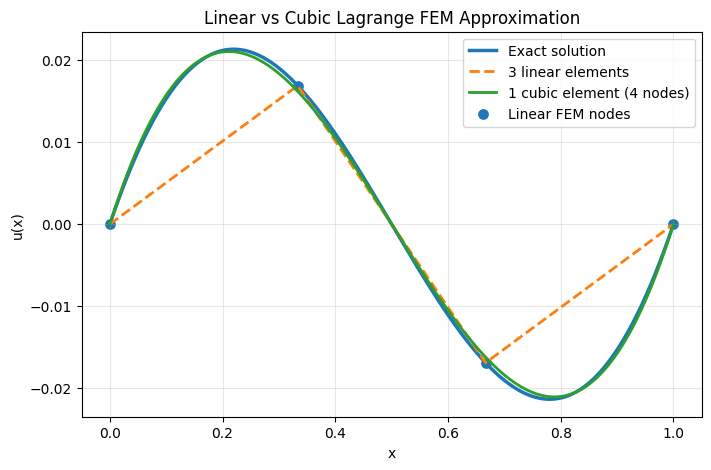

In [94]:
def u_exact(x):
    return (np.cos(np.pi*x) + 2*x - 1) / np.pi**2

u_exact_plot = u_exact(x_plot)

plt.figure(figsize=(8, 5))

plt.plot(x_plot, u_exact_plot, linewidth=2.5, label="Exact solution")
plt.plot(
    x_linear_plot,
    u_linear_plot,
    "--",
    linewidth=2,
    label="3 linear elements"
)
plt.plot(
    x_plot,
    u_cubic_plot,
    linewidth=2,
    label="1 cubic element (4 nodes)"
)

plt.scatter(nodes_float, U_linear, s=45, label="Linear FEM nodes")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Linear vs Cubic Lagrange FEM Approximation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

---
# Problem 2: 1-D Heat Conduction

Consider

$$
-\frac{d}{dx}
\left(
kA\frac{dT}{dx}
\right)
=
q'''A
$$

with

$$
L=0.30\ {\rm m},
\qquad
k=10\ {\rm W/(m\,K)},
$$

$$
A=0.01\ {\rm m^2},
\qquad
q'''=10,000\ {\rm W/m^3}.
$$

Boundary conditions:

$$
T(0)=100^\circ{\rm C}
$$

and

$$
-kA\frac{dT}{dx}\bigg|_{x=L}
=
hA[T(L)-T_\infty],
$$

where

$$
h=20\ {\rm W/(m^2K)},
\qquad
T_\infty=25^\circ{\rm C}.
$$

Again, use three uniform 2-node linear elements.

# 12. Weak form for the heat-transfer problem

After integration by parts,

$$
\boxed{
\int_0^L
kA T'v'\,dx
+
hA\,T(L)v(L)
=
\int_0^L
q'''A v\,dx
+
hAT_\infty v(L)
}.
$$

This example emphasizes two different boundary-condition treatments:

- $T(0)=100^\circ{\rm C}$ is an **essential boundary condition**.
- Convection at $x=L$ contributes naturally to the **global matrix and force vector**.

In [95]:
# Physical parameters
L = sp.Rational(3, 10)       # 0.30 m
k = sp.Rational(10, 1)
A = sp.Rational(1, 100)      # 0.01 m^2
q = sp.Rational(10000, 1)

h = 20.0
T_inf = 25.0
T_left = 100.0

# Four uniformly spaced physical nodes
heat_nodes = [
    sp.Rational(0, 1),
    sp.Rational(1, 10),
    sp.Rational(2, 10),
    sp.Rational(3, 10)
]

heat_nodes_float = np.array([float(value) for value in heat_nodes])

print("Heat-transfer nodes =", heat_nodes_float)

Heat-transfer nodes = [0.  0.1 0.2 0.3]


# 13. Assemble the three heat-conduction elements

For every element we again generate the two Lagrange basis functions directly from its physical node locations.

The element equations are

$$
K_{ij}^e
=
\int_{x_a}^{x_b}
kA
\frac{dN_i}{dx}
\frac{dN_j}{dx}\,dx
$$

and

$$
F_i^e
=
\int_{x_a}^{x_b}
q'''A N_i\,dx.
$$

In [96]:
K_heat = np.zeros((4, 4))
F_heat = np.zeros(4)

for e in range(3):

    local_nodes = [heat_nodes[e], heat_nodes[e + 1]]

    N = [
        sp.simplify(lagrange_basis(x, local_nodes, 0)),
        sp.simplify(lagrange_basis(x, local_nodes, 1))
    ]

    Ke = sp.zeros(2, 2)
    Fe = sp.zeros(2, 1)

    for i in range(2):

        for j in range(2):

            Ke[i, j] = sp.integrate(
                k*A*sp.diff(N[i], x)*sp.diff(N[j], x),
                (x, local_nodes[0], local_nodes[1])
            )

        Fe[i] = sp.integrate(
            q*A*N[i],
            (x, local_nodes[0], local_nodes[1])
        )

    print(f"\nElement {e+1}")
    print("Ke =")
    sp.pprint(Ke)

    print("Fe =")
    sp.pprint(Fe)

    dofs = [e, e + 1]

    # Assembly
    for i in range(2):

        F_heat[dofs[i]] += float(Fe[i])

        for j in range(2):
            K_heat[dofs[i], dofs[j]] += float(Ke[i, j])

print("\nAfter assembling the three conduction elements:")

print("\nK =")
print(K_heat)

print("\nF =")
print(F_heat)


Element 1
Ke =
⎡1   -1⎤
⎢      ⎥
⎣-1  1 ⎦
Fe =
⎡5⎤
⎢ ⎥
⎣5⎦

Element 2
Ke =
⎡1   -1⎤
⎢      ⎥
⎣-1  1 ⎦
Fe =
⎡5⎤
⎢ ⎥
⎣5⎦

Element 3
Ke =
⎡1   -1⎤
⎢      ⎥
⎣-1  1 ⎦
Fe =
⎡5⎤
⎢ ⎥
⎣5⎦

After assembling the three conduction elements:

K =
[[ 1. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  1.]]

F =
[ 5. 10. 10.  5.]


# 14. Add the convection boundary condition

At the right boundary,

$$
-kA T'(L)
=
hA[T(L)-T_\infty].
$$

From the weak form, this contributes

$$
K_{44}\leftarrow K_{44}+hA
$$

and

$$
F_4\leftarrow F_4+hAT_\infty.
$$

In [97]:
# Convection contribution at the last global node
K_heat[-1, -1] += h * float(A)
F_heat[-1] += h * float(A) * T_inf

print("After adding convection:")

print("\nK =")
print(K_heat)

print("\nF =")
print(F_heat)

After adding convection:

K =
[[ 1.  -1.   0.   0. ]
 [-1.   2.  -1.   0. ]
 [ 0.  -1.   2.  -1. ]
 [ 0.   0.  -1.   1.2]]

F =
[ 5. 10. 10. 10.]


# 15. Apply the prescribed temperature

The first nodal value is known:

$$
T_1=100^\circ{\rm C}.
$$

The unknown temperatures are

$$
T_2,\qquad T_3,\qquad T_4.
$$

In [98]:
fixed = [0]
free = [1, 2, 3]

T = np.zeros(4)
T[0] = T_left

Kff = K_heat[np.ix_(free, free)]
Kfc = K_heat[np.ix_(free, fixed)]

Ff = F_heat[free] - Kfc @ np.array([T_left])

T[free] = np.linalg.solve(Kff, Ff)

print("Nodal temperatures:")

for i in range(4):
    print(
        f"Node {i+1}: x = {heat_nodes_float[i]:.2f} m, "
        f"T = {T[i]:.4f} C"
    )

Nodal temperatures:
Node 1: x = 0.00 m, T = 100.0000 C
Node 2: x = 0.10 m, T = 110.0000 C
Node 3: x = 0.20 m, T = 110.0000 C
Node 4: x = 0.30 m, T = 100.0000 C


# 16. Plot the heat-transfer FEM solution

The linear-element temperature approximation is reconstructed using the same Lagrange basis function.

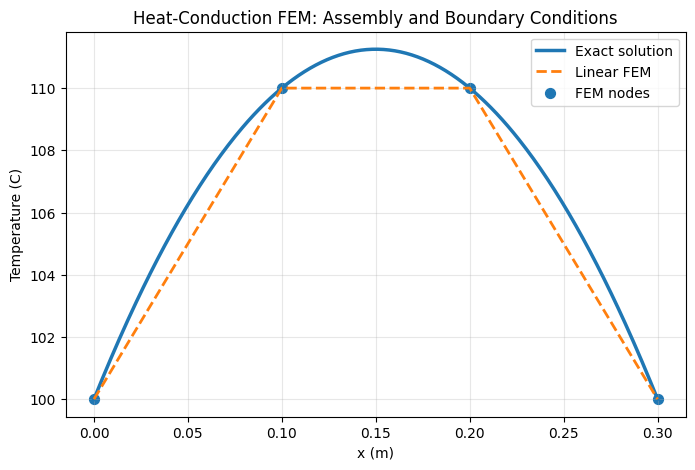

In [99]:
x_heat_plot = []
T_heat_plot = []

for e in range(3):

    xa = heat_nodes_float[e]
    xb = heat_nodes_float[e + 1]

    xe = np.linspace(xa, xb, 100)

    local_nodes = np.array([xa, xb])

    N1 = lagrange_basis(xe, local_nodes, 0)
    N2 = lagrange_basis(xe, local_nodes, 1)

    Te = N1*T[e] + N2*T[e + 1]

    x_heat_plot.extend(xe)
    T_heat_plot.extend(Te)

x_heat_plot = np.array(x_heat_plot)
T_heat_plot = np.array(T_heat_plot)

# Exact solution for comparison
L_float = float(L)
k_float = float(k)
q_float = float(q)

C1 = (
    q_float*L_float
    - h*(T_left - T_inf - q_float*L_float**2/(2*k_float))
) / (k_float + h*L_float)

def T_exact(x):
    return (
        -q_float*x**2/(2*k_float)
        + C1*x
        + T_left
    )

x_exact_heat = np.linspace(0.0, L_float, 400)

plt.figure(figsize=(8, 5))

plt.plot(
    x_exact_heat,
    T_exact(x_exact_heat),
    linewidth=2.5,
    label="Exact solution"
)

plt.plot(
    x_heat_plot,
    T_heat_plot,
    "--",
    linewidth=2,
    label="Linear FEM"
)

plt.scatter(
    heat_nodes_float,
    T,
    s=50,
    label="FEM nodes"
)

plt.xlabel("x (m)")
plt.ylabel("Temperature (C)")
plt.title("Heat-Conduction FEM: Assembly and Boundary Conditions")
plt.grid(alpha=0.3)
plt.legend()
plt.show()